   # Modelo de predição Score de crédito


 # 1_fase: Importando bibliotecas

In [453]:
import pandas as pd 
import numpy as np
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [454]:
%matplotlib inline

 # 2_fase: Lendo o DataFrame

 ### *Essa parte tem o objetivo de trazer os dados, ver se estão corretos, e ajudar a facilitar a leitura posteriormente*

 ### Trazendo o df atravéz do pandas e vendo se veio corretamente

In [455]:
df = pd.read_csv("dados_usados/lending_club_loan_two.csv")

 Vendo as 5 primeiras linhas

In [456]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


 Vendo as ultimas 5 linhas

In [457]:
df.tail()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
396025,10000.0,60 months,10.99,217.38,B,B4,licensed bankere,2 years,RENT,40000.0,...,6.0,0.0,1990.0,34.3,23.0,w,INDIVIDUAL,0.0,0.0,"12951 Williams Crossing\r\nJohnnyville, DC 30723"
396026,21000.0,36 months,12.29,700.42,C,C1,Agent,5 years,MORTGAGE,110000.0,...,6.0,0.0,43263.0,95.7,8.0,f,INDIVIDUAL,1.0,0.0,"0114 Fowler Field Suite 028\r\nRachelborough, ..."
396027,5000.0,36 months,9.99,161.32,B,B1,City Carrier,10+ years,RENT,56500.0,...,15.0,0.0,32704.0,66.9,23.0,f,INDIVIDUAL,0.0,0.0,"953 Matthew Points Suite 414\r\nReedfort, NY 7..."
396028,21000.0,60 months,15.31,503.02,C,C2,"Gracon Services, Inc",10+ years,MORTGAGE,64000.0,...,9.0,0.0,15704.0,53.8,20.0,f,INDIVIDUAL,5.0,0.0,"7843 Blake Freeway Apt. 229\r\nNew Michael, FL..."
396029,2000.0,36 months,13.61,67.98,C,C2,Internal Revenue Service,10+ years,RENT,42996.0,...,3.0,0.0,4292.0,91.3,19.0,f,INDIVIDUAL,NaN,0.0,"787 Michelle Causeway\r\nBriannaton, AR 48052"


 ### Criando um dicionario, para falar o que cada uma significa

In [458]:
colunas_traducao = {
    "loan_amnt": "valor_do_emprestimo",
    "term": "prazo_do_emprestimo_meses",
    "int_rate": "taxa_de_juros",
    "installment": "valor_da_parcela",
    "grade": "classificacao_de_risco",
    "sub_grade": "sub_classificacao_de_risco",
    "emp_title": "cargo_profissao",
    "emp_length": "tempo_de_emprego_anos",
    "home_ownership": "tipo_de_moradia",
    "annual_inc": "renda_anual",
    "verification_status": "status_de_verificacao_da_renda",
    "issue_d": "data_de_emissao_do_emprestimo",
    "loan_status": "status_do_emprestimo",
    "purpose": "finalidade_do_emprestimo",
    "title": "titulo_descricao_do_emprestimo",
    "dti": "relacao_divida_renda",
    "earliest_cr_line": "primeira_linha_de_credito",
    "open_acc": "contas_de_credito_abertas",
    "pub_rec": "registros_publicos_negativos",
    "revol_bal": "saldo_de_credito_rotativo",
    "revol_util": "utilizacao_do_credito_rotativo",
    "total_acc": "total_de_contas_de_credito",
    "initial_list_status": "status_inicial_de_listagem",
    "application_type": "tipo_de_aplicacao",
    "mort_acc": "contas_de_hipoteca",
    "pub_rec_bankruptcies": "registros_de_falencia",
    "address": "endereco"
}

 ### Renomeando as colunas

In [459]:
df = df.rename(columns = colunas_traducao)

 ### Observando se está certo

In [460]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   valor_do_emprestimo             396030 non-null  float64
 1   prazo_do_emprestimo_meses       396030 non-null  object 
 2   taxa_de_juros                   396030 non-null  float64
 3   valor_da_parcela                396030 non-null  float64
 4   classificacao_de_risco          396030 non-null  object 
 5   sub_classificacao_de_risco      396030 non-null  object 
 6   cargo_profissao                 373103 non-null  object 
 7   tempo_de_emprego_anos           377729 non-null  object 
 8   tipo_de_moradia                 396030 non-null  object 
 9   renda_anual                     396030 non-null  float64
 10  status_de_verificacao_da_renda  396030 non-null  object 
 11  data_de_emissao_do_emprestimo   396030 non-null  object 
 12  status_do_empres

 # 3_fase: Analisando e limpando dados

 ### Nessa parte há o objetivo de tirar dados com pouca importancia, ver o que fazer com dados nulos, e organizar para tudo se transformar em dados númericos para ser lido pelo modelo

 ### 3.1: Limpando os dados

 ### Tirando dados que pouca importância

In [461]:
df = df.drop(["titulo_descricao_do_emprestimo", "cargo_profissao", "status_inicial_de_listagem", "status_de_verificacao_da_renda"], axis=1)

 ### Observando se há dados vazios

In [462]:
df.isnull().sum()

valor_do_emprestimo                   0
prazo_do_emprestimo_meses             0
taxa_de_juros                         0
valor_da_parcela                      0
classificacao_de_risco                0
sub_classificacao_de_risco            0
tempo_de_emprego_anos             18301
tipo_de_moradia                       0
renda_anual                           0
data_de_emissao_do_emprestimo         0
status_do_emprestimo                  0
finalidade_do_emprestimo              0
relacao_divida_renda                  0
primeira_linha_de_credito             0
contas_de_credito_abertas             0
registros_publicos_negativos          0
saldo_de_credito_rotativo             0
utilizacao_do_credito_rotativo      276
total_de_contas_de_credito            0
tipo_de_aplicacao                     0
contas_de_hipoteca                37795
registros_de_falencia               535
endereco                              0
dtype: int64

 ### olhando se o tipo dos dados são númericos para conseguir completar os dados com medianas, e não perder dados significativos

In [463]:
df["contas_de_hipoteca"].value_counts()

contas_de_hipoteca
0.0     139777
1.0      60416
2.0      49948
3.0      38049
4.0      27887
5.0      18194
6.0      11069
7.0       6052
8.0       3121
9.0       1656
10.0       865
11.0       479
12.0       264
13.0       146
14.0       107
15.0        61
16.0        37
17.0        22
18.0        18
19.0        15
20.0        13
24.0        10
22.0         7
21.0         4
25.0         4
27.0         3
26.0         2
32.0         2
31.0         2
23.0         2
34.0         1
28.0         1
30.0         1
Name: count, dtype: int64

In [464]:
df["registros_de_falencia"].value_counts()

registros_de_falencia
0.0    350380
1.0     42790
2.0      1847
3.0       351
4.0        82
5.0        32
6.0         7
7.0         4
8.0         2
Name: count, dtype: int64

In [465]:
df["utilizacao_do_credito_rotativo"].value_counts()

utilizacao_do_credito_rotativo
0.00      2213
53.00      752
60.00      739
61.00      734
55.00      730
          ... 
146.10       1
109.30       1
108.10       1
115.30       1
37.63        1
Name: count, Length: 1226, dtype: int64

 ### Completando os dados que faltam nessas colunas com medianas considerando todos os valores que ja existem na sua coluna

In [466]:
df["utilizacao_do_credito_rotativo"] = df["utilizacao_do_credito_rotativo"].fillna(df["utilizacao_do_credito_rotativo"].median())
df["contas_de_hipoteca"] = df["contas_de_hipoteca"].fillna(df["contas_de_hipoteca"].median())
df["registros_de_falencia"] = df["registros_de_falencia"].fillna(df["registros_de_falencia"].median())

 ### Olhando os dados que faltam

In [467]:
df.isna().sum()

valor_do_emprestimo                   0
prazo_do_emprestimo_meses             0
taxa_de_juros                         0
valor_da_parcela                      0
classificacao_de_risco                0
sub_classificacao_de_risco            0
tempo_de_emprego_anos             18301
tipo_de_moradia                       0
renda_anual                           0
data_de_emissao_do_emprestimo         0
status_do_emprestimo                  0
finalidade_do_emprestimo              0
relacao_divida_renda                  0
primeira_linha_de_credito             0
contas_de_credito_abertas             0
registros_publicos_negativos          0
saldo_de_credito_rotativo             0
utilizacao_do_credito_rotativo        0
total_de_contas_de_credito            0
tipo_de_aplicacao                     0
contas_de_hipoteca                    0
registros_de_falencia                 0
endereco                              0
dtype: int64

 ### Pegando a coluna que ainda tem dados faltando e aproveitando para mexer em outra que também é data

 ### Olhando como a coluna "tempo_de_emprego_anos" está organizada

In [468]:
df["tempo_de_emprego_anos"].value_counts()

tempo_de_emprego_anos
10+ years    126041
2 years       35827
< 1 year      31725
3 years       31665
5 years       26495
1 year        25882
4 years       23952
6 years       20841
7 years       20819
8 years       19168
9 years       15314
Name: count, dtype: int64

 ### Criando um dicionario para transformar os dados dela em inteiros

In [469]:
tempo_emprego = {
"10+ years" : 10,
"2 years" : 2,
"< 1 year" : 0,
"3 years" : 3,
"5 years" : 5,
"1 year" : 1, 
"4 years" : 4, 
"6 years" : 6,
"7 years" : 7 , 
"8 years" : 8,
"9 years" : 9
}

 ### Olhando a outra coluna que também é data e classificada como objeto

In [470]:
df["prazo_do_emprestimo_meses"].value_counts()

prazo_do_emprestimo_meses
36 months    302005
60 months     94025
Name: count, dtype: int64

 ### Uma para resolver passei uma função map que passa o dicionario e muda os dados pelas correções que estão no proprio dicionario, e em outro so tirei o "months" e mudei para "int" as respostas

In [471]:
df["tempo_de_emprego_anos"] = df["tempo_de_emprego_anos"].map(tempo_emprego)
df["prazo_do_emprestimo_meses"] = df["prazo_do_emprestimo_meses"].str.replace("months", "").astype(int)

 ### Olhando se está tudo certo

In [472]:
df["tempo_de_emprego_anos"].value_counts()

tempo_de_emprego_anos
10.0    126041
2.0      35827
0.0      31725
3.0      31665
5.0      26495
1.0      25882
4.0      23952
6.0      20841
7.0      20819
8.0      19168
9.0      15314
Name: count, dtype: int64

In [473]:
df["prazo_do_emprestimo_meses"].value_counts()

prazo_do_emprestimo_meses
36    302005
60     94025
Name: count, dtype: int64

 ### Agora completo os dados que estavam faltando na coluna "tempo_de_emprego_anos"

In [474]:
df["tempo_de_emprego_anos"] = df["tempo_de_emprego_anos"].replace(np.nan, df["tempo_de_emprego_anos"].median())

 ### Olho com "sample" para vir os dados aleatoriamente das linhas na coluna e vêr se deu certo

In [475]:
df["tempo_de_emprego_anos"].sample(20)

242211     3.0
136614     8.0
334487     7.0
286266     2.0
321600     2.0
231505    10.0
164012     6.0
173202     0.0
6177      10.0
311278     3.0
288963     1.0
139508    10.0
323088    10.0
285079     9.0
359927     8.0
40989      7.0
334349     5.0
201776     0.0
167130    10.0
4666      10.0
Name: tempo_de_emprego_anos, dtype: float64

 ### Tirando colunas que não sei qual foi o criterio para serem classificadas e meu modelo irá tenter prever essa resposta, então não faz sentido telas

In [476]:
df = df.drop(["classificacao_de_risco", "sub_classificacao_de_risco"], axis=1)

 ### Olhando se tem mais alguma colunas sem dados

In [477]:
df.isnull().sum()

valor_do_emprestimo               0
prazo_do_emprestimo_meses         0
taxa_de_juros                     0
valor_da_parcela                  0
tempo_de_emprego_anos             0
tipo_de_moradia                   0
renda_anual                       0
data_de_emissao_do_emprestimo     0
status_do_emprestimo              0
finalidade_do_emprestimo          0
relacao_divida_renda              0
primeira_linha_de_credito         0
contas_de_credito_abertas         0
registros_publicos_negativos      0
saldo_de_credito_rotativo         0
utilizacao_do_credito_rotativo    0
total_de_contas_de_credito        0
tipo_de_aplicacao                 0
contas_de_hipoteca                0
registros_de_falencia             0
endereco                          0
dtype: int64

 ### Olhando o tipo das colunas agora, para pensar em o que fazer

In [478]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 21 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   valor_do_emprestimo             396030 non-null  float64
 1   prazo_do_emprestimo_meses       396030 non-null  int64  
 2   taxa_de_juros                   396030 non-null  float64
 3   valor_da_parcela                396030 non-null  float64
 4   tempo_de_emprego_anos           396030 non-null  float64
 5   tipo_de_moradia                 396030 non-null  object 
 6   renda_anual                     396030 non-null  float64
 7   data_de_emissao_do_emprestimo   396030 non-null  object 
 8   status_do_emprestimo            396030 non-null  object 
 9   finalidade_do_emprestimo        396030 non-null  object 
 10  relacao_divida_renda            396030 non-null  float64
 11  primeira_linha_de_credito       396030 non-null  object 
 12  contas_de_credit

 ### Criando um laço que separa as colunas que são númericas e as que são textos para ver como está cada

In [479]:
colunas_numericas = []
colunas_texto = []
for i in df.columns.tolist():
  if df[i].dtype == "int64" or df[i].dtype == "float64":
     colunas_numericas.append(i)
  else:
     colunas_texto.append(i)

In [480]:
colunas_numericas

['valor_do_emprestimo',
 'prazo_do_emprestimo_meses',
 'taxa_de_juros',
 'valor_da_parcela',
 'tempo_de_emprego_anos',
 'renda_anual',
 'relacao_divida_renda',
 'contas_de_credito_abertas',
 'registros_publicos_negativos',
 'saldo_de_credito_rotativo',
 'utilizacao_do_credito_rotativo',
 'total_de_contas_de_credito',
 'contas_de_hipoteca',
 'registros_de_falencia']

In [481]:
colunas_texto

['tipo_de_moradia',
 'data_de_emissao_do_emprestimo',
 'status_do_emprestimo',
 'finalidade_do_emprestimo',
 'primeira_linha_de_credito',
 'tipo_de_aplicacao',
 'endereco']

 ### Tirando algumas coulunas que poderiam ser importantes, mas pesaria muito o processamento para esse teste, em um trabalho importante, com muito mais dados e um bom computador talvez valeria a pena

In [482]:
df = df.drop(["endereco", "data_de_emissao_do_emprestimo", "primeira_linha_de_credito"], axis=1)

 ### 3.2: Codificando as colunas objetos para númericas

 ### Separando as colunas que são objetos, exceto a do "status_do_emprestimo" que a maquina irá tentar prever, criando um codificador que fará cada resposta diferente em cada coluna virar número e ainda deixando o nome da coluna que estava no df do pandas, depois de transformar junta com as colunas inteiras que ja tinham no df, fazendo um df_modelo

In [483]:
colunas_codificadas = df.select_dtypes(include="object").columns.drop("status_do_emprestimo")

codificador = OneHotEncoder(sparse_output=False, drop="first").set_output(transform="pandas")
df_codificado = codificador.fit_transform(df[colunas_codificadas])
df_modelo = pd.concat([df.drop(colunas_codificadas, axis=1), df_codificado], axis=1)

In [484]:
colunas_codificadas

Index(['tipo_de_moradia', 'finalidade_do_emprestimo', 'tipo_de_aplicacao'], dtype='object')

 ### Observando se está correto

In [485]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 35 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   valor_do_emprestimo                          396030 non-null  float64
 1   prazo_do_emprestimo_meses                    396030 non-null  int64  
 2   taxa_de_juros                                396030 non-null  float64
 3   valor_da_parcela                             396030 non-null  float64
 4   tempo_de_emprego_anos                        396030 non-null  float64
 5   renda_anual                                  396030 non-null  float64
 6   status_do_emprestimo                         396030 non-null  object 
 7   relacao_divida_renda                         396030 non-null  float64
 8   contas_de_credito_abertas                    396030 non-null  float64
 9   registros_publicos_negativos                 396030 non-nul

 ### Transformando separadamente o "status_do_emprestimo"

In [486]:
df["status_do_emprestimo"].value_counts()

status_do_emprestimo
Fully Paid     318357
Charged Off     77673
Name: count, dtype: int64

In [487]:
status_emprestimo = {
"Fully Paid" : 1,
"Charged Off" : 0
}

In [488]:
df_modelo["status_do_emprestimo"] = df_modelo["status_do_emprestimo"].map(status_emprestimo)

 ### Deixando em primeiro só para não ficar caçando no gráfico de correlação

In [489]:
df_modelo.set_index("status_do_emprestimo", inplace=True)

In [490]:
df_modelo.reset_index(inplace=True)

In [491]:
df_modelo.sample(20)

,status_do_emprestimo,valor_do_emprestimo,prazo_do_emprestimo_meses,taxa_de_juros,valor_da_parcela,tempo_de_emprego_anos,renda_anual,relacao_divida_renda,contas_de_credito_abertas,registros_publicos_negativos,...,finalidade_do_emprestimo_major_purchase,finalidade_do_emprestimo_medical,finalidade_do_emprestimo_moving,finalidade_do_emprestimo_other,finalidade_do_emprestimo_renewable_energy,finalidade_do_emprestimo_small_business,finalidade_do_emprestimo_vacation,finalidade_do_emprestimo_wedding,tipo_de_aplicacao_INDIVIDUAL,tipo_de_aplicacao_JOINT
239769,1,8000.0,36,7.88,250.25,5.0,66500.0,19.65,10.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15891,1,15000.0,36,12.29,500.30,5.0,82000.0,15.26,8.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
39955,1,12000.0,36,10.99,392.81,4.0,52000.0,27.49,10.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
100596,1,5000.0,36,10.71,163.01,4.0,30000.0,20.28,13.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
93478,0,4175.0,36,24.24,164.33,6.0,20000.0,15.19,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
235279,1,12225.0,36,16.29,431.55,10.0,34000.0,26.93,10.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
28628,0,1200.0,36,16.99,42.78,10.0,60000.0,17.50,12.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
387938,1,8800.0,36,15.99,309.34,3.0,43000.0,35.45,14.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
383315,1,8075.0,36,14.99,279.89,7.0,32000.0,11.97,8.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
84718,0,10000.0,36,8.90,317.54,7.0,32908.0,26.04,13.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


 # 4_fase: Criando gŕaficos e analisando

 ### 4.1 Gráfico de correlação

<bound method Figure.show of <Figure size 3000x800 with 2 Axes>>

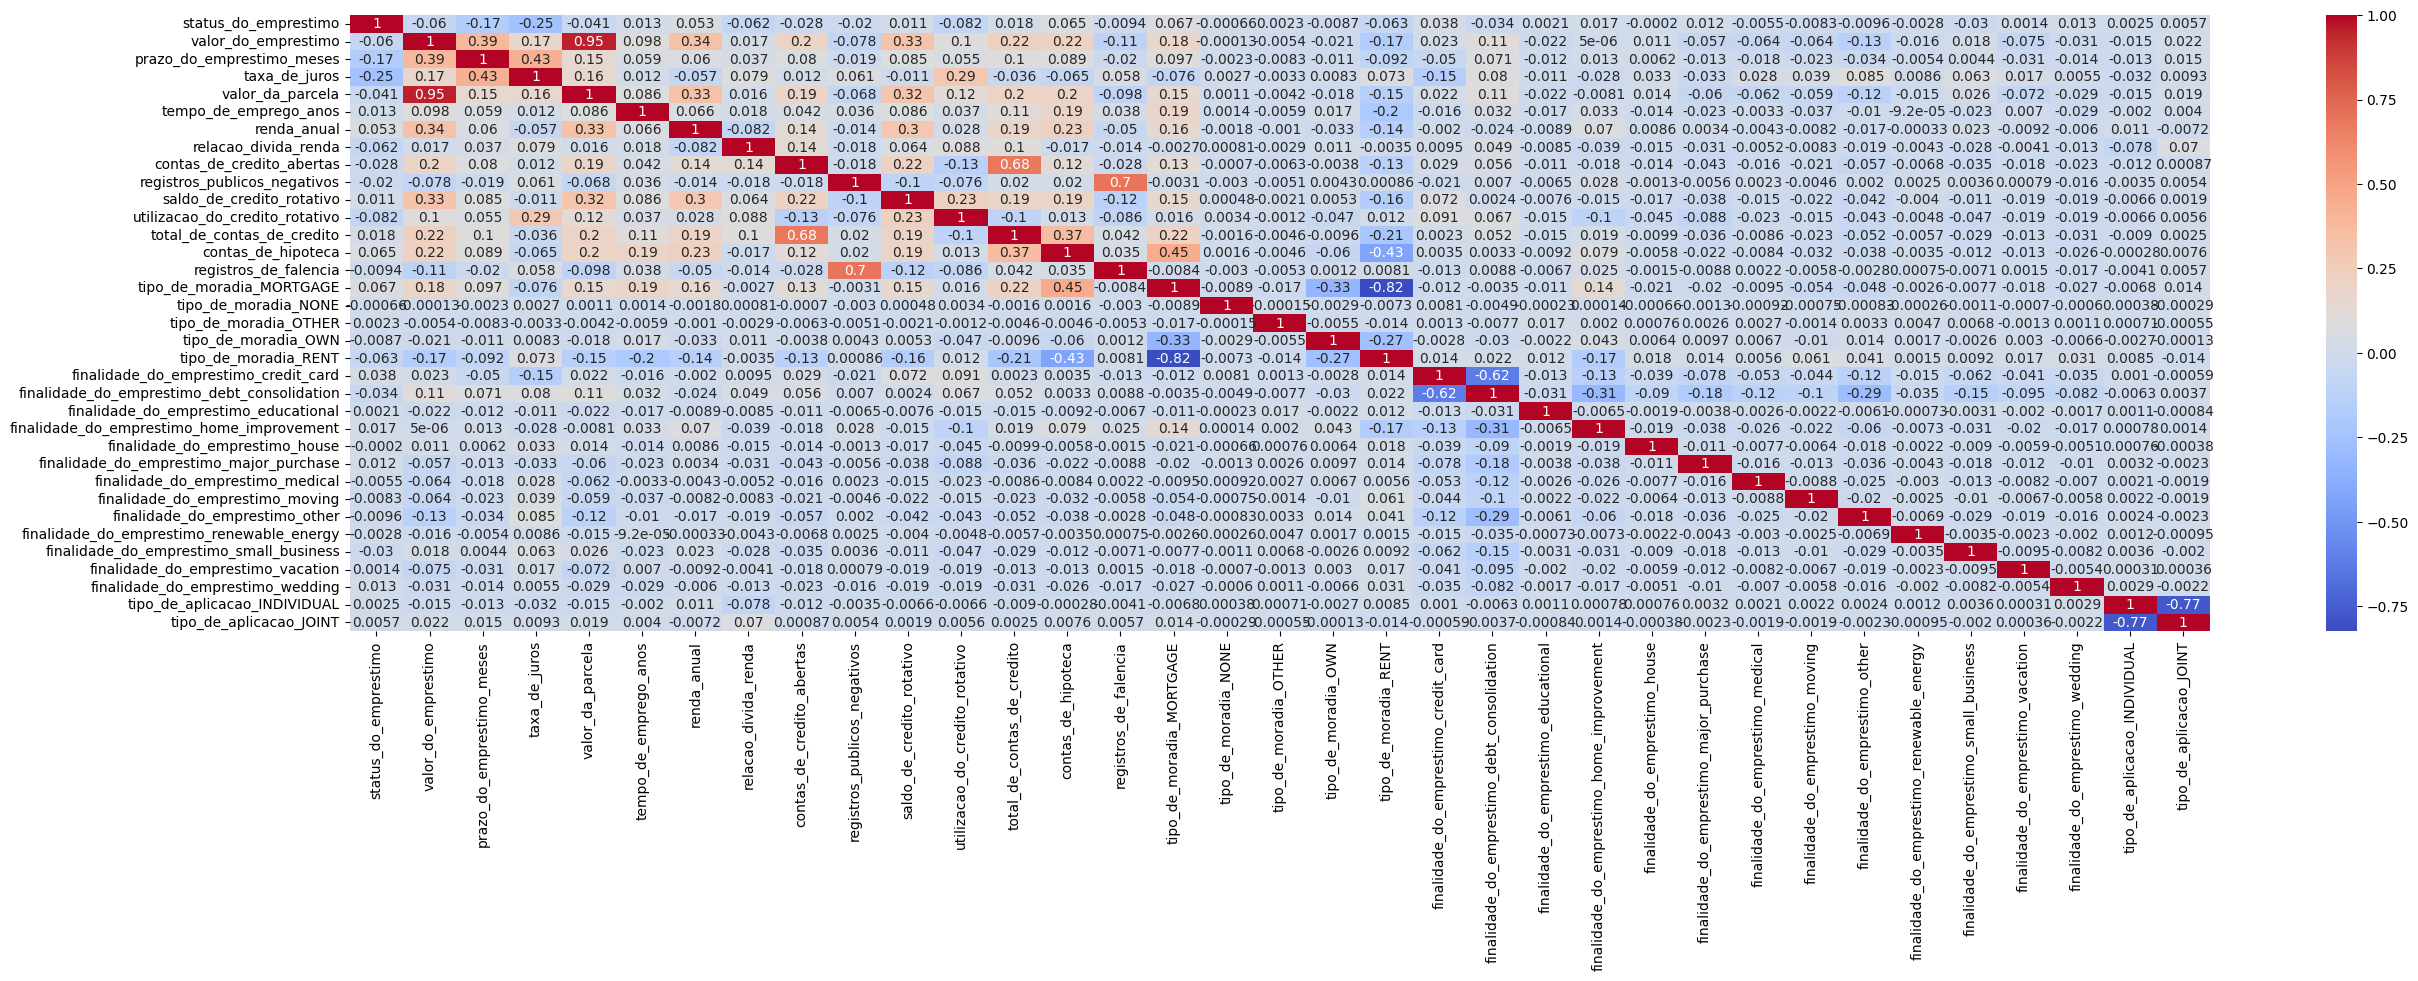

In [492]:
corr = df_modelo.corr()

grafico_calor = plt.figure(figsize=(30, 8))

sns.heatmap(corr, annot=True, cmap= "coolwarm")

grafico_calor.show

 ##### Aqui pode ser visto que não existe nenhum separadamente que tem muita relação com o "status_do_emprestimo", apenas um pouco a "taxa_de_juros"

### 4.2: Caçando Outliers


#####  *Será feito somente nos que podem ser muito fora do comum*

### criando uma função para criar gráficos boxplot com as colunas que eu colocar

In [493]:
def analisar_outlier(i):
 grafico_outlier = plt.figure(figsize=(12, 8))


 sns.boxplot(data = df_modelo, x=i)

 grafico_outlier.show()

### Analisando o número de contas, que é uma coluna que pode ter grandes outliers

/tmp/ipykernel_3803/253619274.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  grafico_outlier.show()


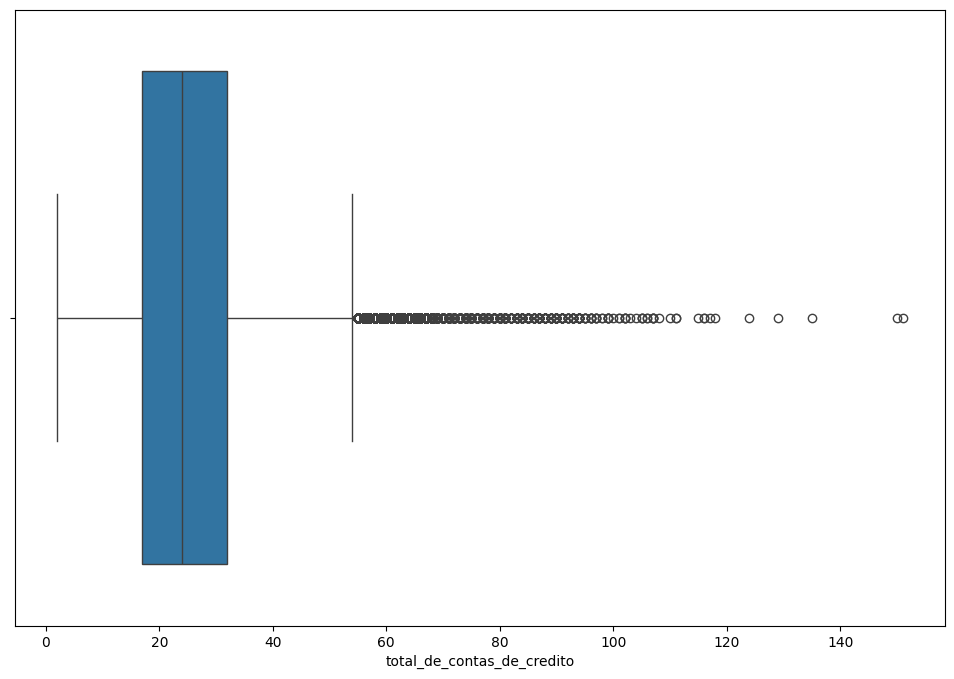

In [494]:
analisar_outlier("total_de_contas_de_credito")

##### Aqui pode-se ver que existe outliers, porque embora possivel, muito dificilmente alguém teria mais de 60 contas de créditos

### Olhando como esta essa divisão caçando os valores fora da curva

In [495]:
df_modelo["total_de_contas_de_credito"].value_counts()

total_de_contas_de_credito
21.0     14280
22.0     14260
20.0     14228
23.0     13923
24.0     13878
         ...  
150.0        1
117.0        1
115.0        1
100.0        1
103.0        1
Name: count, Length: 118, dtype: int64

### Organizando para não trazer esses dados absurdos para o modelo

In [496]:
df_modelo = df_modelo[df_modelo["total_de_contas_de_credito"] < 60]

In [497]:
(df_modelo["total_de_contas_de_credito"].value_counts() > 60).sum()

np.int64(57)

In [498]:
df_modelo["total_de_contas_de_credito"].value_counts()

total_de_contas_de_credito
21.0    14280
22.0    14260
20.0    14228
23.0    13923
24.0    13878
19.0    13876
18.0    13710
17.0    13495
25.0    13225
26.0    12799
16.0    12771
27.0    12343
15.0    12283
28.0    11706
14.0    11524
29.0    11274
13.0    10936
30.0    10587
31.0     9869
12.0     9858
32.0     9552
11.0     8844
33.0     8682
34.0     8088
10.0     7672
35.0     7406
36.0     6971
37.0     6362
9.0      6362
38.0     5707
39.0     5428
8.0      5365
40.0     4896
41.0     4391
7.0      4143
42.0     4072
43.0     3637
44.0     3408
45.0     2991
6.0      2923
46.0     2626
47.0     2426
48.0     2197
5.0      2028
49.0     1912
50.0     1747
51.0     1529
52.0     1447
53.0     1245
4.0      1238
54.0     1066
55.0      993
56.0      864
57.0      758
58.0      715
59.0      645
3.0       327
2.0        18
Name: count, dtype: int64

### Analisando o número de contas abertas 

/tmp/ipykernel_3803/253619274.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  grafico_outlier.show()


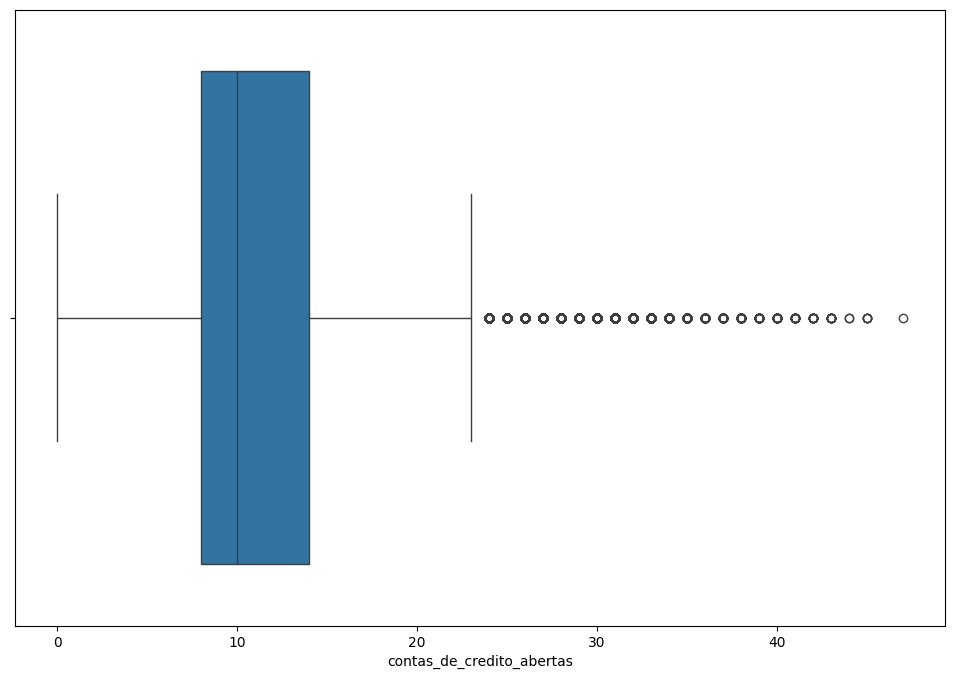

In [499]:
analisar_outlier("contas_de_credito_abertas")

##### Pode-se ver dados absurdos aqui também, muito improvavel alguém ter mais de 25 contas de creditos abertas e não está inadimplente 

### Analisando e corrigindo essa coluna

In [500]:
df["contas_de_credito_abertas"].value_counts()

contas_de_credito_abertas
9.0     36779
10.0    35441
8.0     35137
11.0    32695
7.0     31328
        ...  
56.0        2
55.0        2
57.0        1
58.0        1
90.0        1
Name: count, Length: 61, dtype: int64

In [501]:
df_modelo = df_modelo[df_modelo["contas_de_credito_abertas"] < 25]

In [502]:
df_modelo["contas_de_credito_abertas"].value_counts()

contas_de_credito_abertas
9.0     36716
10.0    35348
8.0     35099
11.0    32581
7.0     31297
12.0    29035
6.0     25918
13.0    24856
14.0    21036
5.0     18301
15.0    17154
16.0    14207
17.0    11443
4.0     10708
18.0     9190
19.0     7506
20.0     5766
3.0      4782
21.0     4469
22.0     3479
23.0     2755
24.0     2159
2.0      1459
1.0        85
0.0         6
Name: count, dtype: int64

/tmp/ipykernel_3803/253619274.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  grafico_outlier.show()


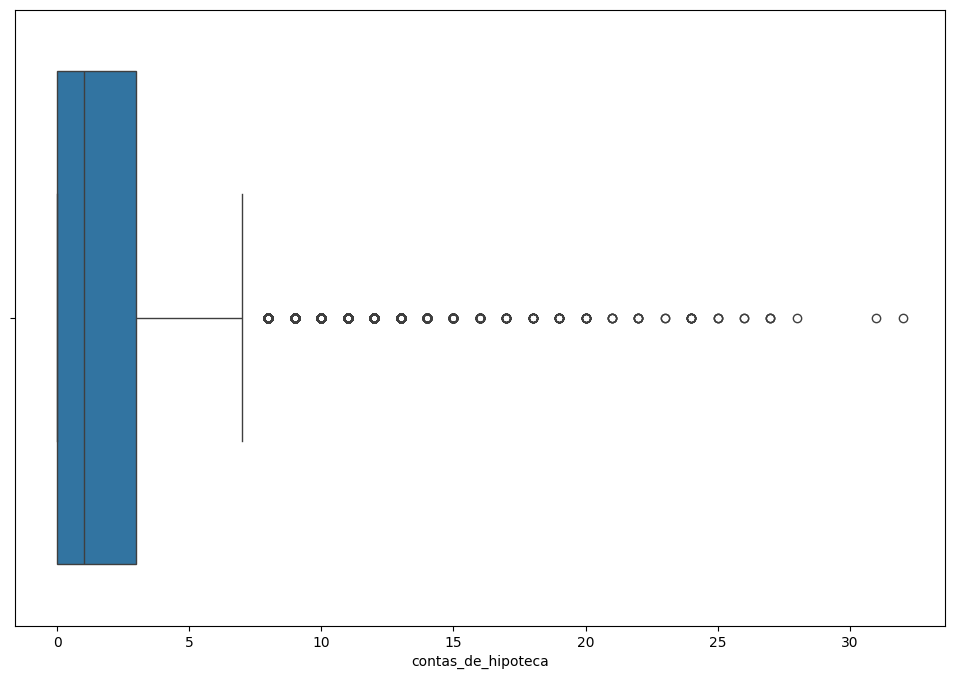

In [503]:
analisar_outlier("contas_de_hipoteca")

##### Aqui há um forte outlier, porque se em contgas de crédito abertas mais de 25 é raro, em hipotecas mais de 10 é rarissimo

### Organizando os dados

In [504]:
df_modelo["contas_de_hipoteca"].value_counts()

contas_de_hipoteca
0.0     136700
1.0      96210
2.0      48395
3.0      36815
4.0      26859
5.0      17531
6.0      10608
7.0       5787
8.0       2953
9.0       1563
10.0       820
11.0       454
12.0       248
13.0       136
14.0        95
15.0        58
16.0        36
17.0        19
19.0        14
18.0        13
20.0        11
24.0         8
22.0         5
21.0         4
25.0         3
27.0         3
23.0         2
26.0         2
31.0         1
28.0         1
32.0         1
Name: count, dtype: int64

In [505]:
df_modelo = df_modelo[df_modelo["contas_de_hipoteca"] < 10]

In [506]:
df_modelo["contas_de_hipoteca"].value_counts()

contas_de_hipoteca
0.0    136700
1.0     96210
2.0     48395
3.0     36815
4.0     26859
5.0     17531
6.0     10608
7.0      5787
8.0      2953
9.0      1563
Name: count, dtype: int64

##### Esssas eram as principais colunas que pensei ter possiveis outiliers muito fora da curva e iriam ter dados que pesasssem muito mais que outros por casos rarissimos

### Fazendo o upload do DataFrame para ser analisado em outro ambiente focado na criação do modelo

In [507]:
df_modelo.to_csv("dados_usados/dados_para_modelo.csv", sep=",", encoding="utf-8", index=False)